# Bibliotecas

In [ ]:
import cv2
import matplotlib
import numpy as np
import imutils
from skimage.filters import threshold_otsu
import pytesseract
import re

# É necessário instalar o arquivo tesseract.exe, da biblioteca pytesseract
pytesseract.pytesseract.tesseract_cmd = r"C:\Users\andre23035\AppData\Local\Programs\Tesseract-OCR\tesseract.exe" 

print("Versão do OpenCV:", cv2.__version__)
print("Versão do Matplotlib:", matplotlib.__version__)
print("Versão do Numpy:", np.__version__)
print("Versão do Imutils:", imutils.__version__)

import matplotlib.pyplot as plt


Versão do OpenCV: 4.11.0
Versão do Matplotlib: 3.8.2
Versão do Numpy: 1.26.3
Versão do Imutils: 0.5.4


C:\Users\andre23035\AppData\Roaming\Python\Python311\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# Funções

In [2]:
def recorte_manual(img_1, max_width=1000):
    """
    Abre uma imagem e permite desenhar manualmente um polígono para recorte.
    Retorna a imagem recortada (em RGB) e exibe com matplotlib.
    """
    if img_1 is None:
        raise FileNotFoundError(f"Imagem não encontrada: {img_1}")
    
    img = img_1

    # Redimensionar mantendo a proporção
    scale = max_width / img.shape[1] if img.shape[1] > max_width else 1.0
    new_size = (int(img.shape[1] * scale), int(img.shape[0] * scale))
    img_resized = cv2.resize(img, new_size, interpolation=cv2.INTER_AREA)

    # Cópia para desenhar
    img_display = img_resized.copy()

    # Lista de pontos clicados
    points = []

    # Função para capturar cliques
    def mouse_draw(event, x, y, flags, param):
        nonlocal points, img_display
        if event == cv2.EVENT_LBUTTONDOWN:
            points.append((x, y))
            if len(points) > 1:
                cv2.line(img_display, points[-2], points[-1], (0, 0, 255), 2)
            cv2.circle(img_display, (x, y), 3, (0, 0, 0), -1)

    # Janela
    cv2.namedWindow("Tracejo")
    cv2.setMouseCallback("Tracejo", mouse_draw)

    while True:
        cv2.imshow("Tracejo", img_display)
        key = cv2.waitKey(1) & 0xFF

        if key == ord('r'):
            # Resetar desenho
            img_display = img_resized.copy()
            points = []

        elif key == 13:  # ENTER -> finalizar recorte
            if len(points) > 2:
                # Criar máscara preta
                mask = np.zeros(img_resized.shape[:2], dtype=np.uint8)

                # Desenhar polígono na máscara
                pts = np.array(points, np.int32).reshape((-1, 1, 2))
                cv2.fillPoly(mask, [pts], 255)

                # Criar imagem branca
                recorte = np.ones_like(img_resized, dtype=np.uint8) * 255
                recorte[mask == 255] = img_resized[mask == 255]

                # Encontrar limites do polígono
                xs = [p[0] for p in points]
                ys = [p[1] for p in points]
                x_min, x_max = min(xs), max(xs)
                y_min, y_max = min(ys), max(ys)

                # Fatiar a imagem para o retângulo mínimo
                recorte_cortado = recorte[y_min:y_max+1, x_min:x_max+1]

                # Converter para RGB
                recorte_rgb = cv2.cvtColor(recorte_cortado, cv2.COLOR_BGR2RGB)

                # Mostrar com matplotlib
                plt.figure(figsize=(12, 12))
                plt.imshow(recorte_rgb)
                plt.axis("on")
                plt.show()

                cv2.destroyAllWindows()
                return recorte_rgb

        elif key == 27:  # ESC -> sair sem recorte
            cv2.destroyAllWindows()
            return None
        
def ensure_head_left(img_color):

    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(img_gray, 50, 255, cv2.THRESH_BINARY_INV)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    height, width = img_gray.shape

    large_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > 1000]
    if len(large_contours) == 0:
        return img_color

    x_positions = []
    for cnt in large_contours:
        x, y, w, h = cv2.boundingRect(cnt)
        x_positions.append(x + w / 2) 

    mean_x = np.mean(x_positions)

    if mean_x > width / 2:
        img_color = cv2.flip(img_color, 1)

    return img_color

        

# Exemplo Controle

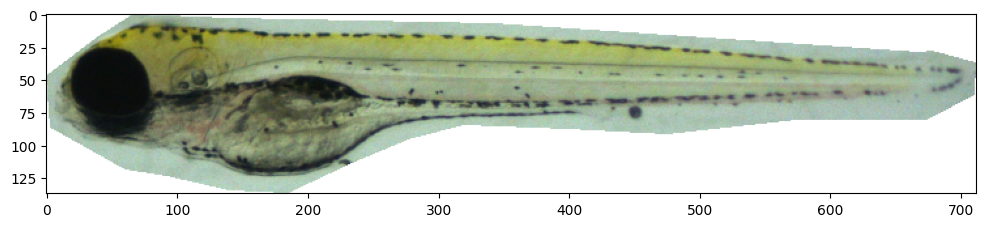

In [22]:
img_path = "images/controle.jpeg"

img_preview = cv2.imread(img_path)
img_recortada = recorte_manual(img_preview)

Texto reconhecido: 1mm

Valor extraído: 1.0


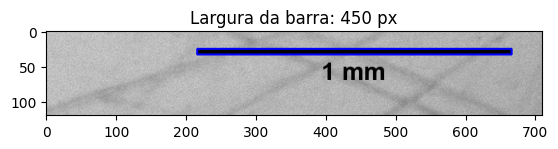

Largura da barra (pixels): 450
Fator de conversão de pixel para mm: 0.0000049 mm/pixel


In [23]:
barra_escala = img_preview.copy()
barra_escala = barra_escala[1800:barra_escala.shape[0],1850:barra_escala.shape[1]]

barra_escala = cv2.cvtColor(barra_escala, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(barra_escala, 50, 255, cv2.THRESH_BINARY_INV)

thresh = cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR)
thresh = cv2.cvtColor(thresh, cv2.COLOR_BGR2GRAY)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

largest_contour = max(contours, key=cv2.contourArea)

x, y, w, h = cv2.boundingRect(largest_contour)

img_color = cv2.cvtColor(barra_escala, cv2.COLOR_GRAY2BGR)
cv2.rectangle(img_color, (x, y), (x+w, y+h), (0, 0, 255), 2)

custom_config = r'--oem 3 --psm 6 -c tessedit_char_whitelist=0123456789.umµ'

texto = pytesseract.image_to_string(barra_escala, config=custom_config)
print("Texto reconhecido:", texto)

match = re.search(r'\d+(?:\.\d+)?', texto)

if match:
    valor = float(match.group())
    print("Valor extraído:", valor)
else:
    print("Número não encontrado")


plt.imshow(img_color)
plt.title(f'Largura da barra: {w} px')
plt.show()

print(f'Largura da barra (pixels): {w}')

fator_conversao = valor/w
fator_conversao = fator_conversao*fator_conversao

print(f'Fator de conversão de pixel para mm: {fator_conversao:.7f} mm/pixel')

fator_conversao = 0.0000049

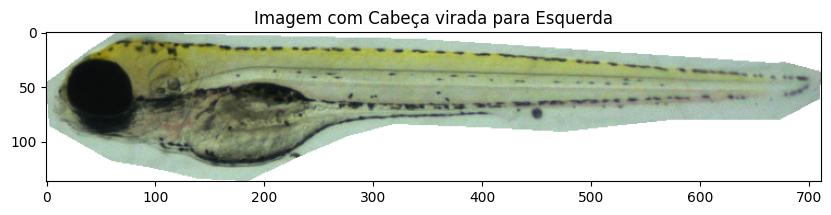

In [24]:
img_color = ensure_head_left(img_recortada)


plt.figure(figsize=(10,5))
plt.imshow(img_color)
plt.title('Imagem com Cabeça virada para Esquerda')
plt.show()


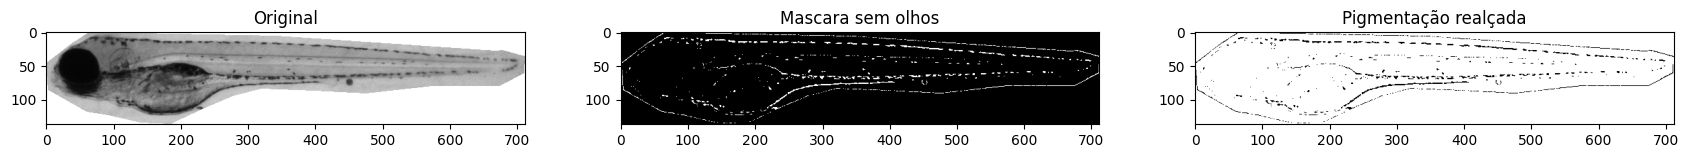

Área pigmentada (sem olhos): 3381 pixels


In [ ]:
img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

x_pig = 9
y_pig = 22

thresh = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY_INV, x_pig, y_pig)
                               #cv2.THRESH_BINARY_INV, 30,35)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

mask_eyes = np.ones_like(img, dtype=np.uint8) * 255
height, width = img.shape

for cnt in contours:
    area = cv2.contourArea(cnt)
    x, y, w, h = cv2.boundingRect(cnt)
    if area > 1000 and x < width * 0.3:
        cv2.drawContours(mask_eyes, [cnt], -1, 3, -1)

# Máscara final sem olhos
pigment_mask = cv2.bitwise_and(thresh, thresh, mask=mask_eyes)

plt.figure(figsize=(21,7)) 
plt.subplot(1,3,1); plt.title('Original'); plt.imshow(img, cmap='gray')
plt.subplot(1,3,2); plt.title('Mascara sem olhos'); plt.imshow(pigment_mask, cmap='gray')
plt.subplot(1,3,3); plt.title('Pigmentação realçada'); plt.imshow(cv2.bitwise_not(pigment_mask), cmap='gray')
plt.show()

pigmented_area = cv2.countNonZero(pigment_mask)
print(f'Área pigmentada (sem olhos): {pigmented_area} pixels')


In [29]:
area_pigmentada = pigmented_area * fator_conversao
print(f'Area Pigmentada: {area_pigmentada:.4f} mm2')
area_pigmentada = area_pigmentada*1000000
print(f'Area Pigmentada: {area_pigmentada:.0f} um2')

Area Pigmentada: 0.0166 mm2
Area Pigmentada: 16567 um2


# Exemplo Bituca sem Tabaco Restante (2 B/L)

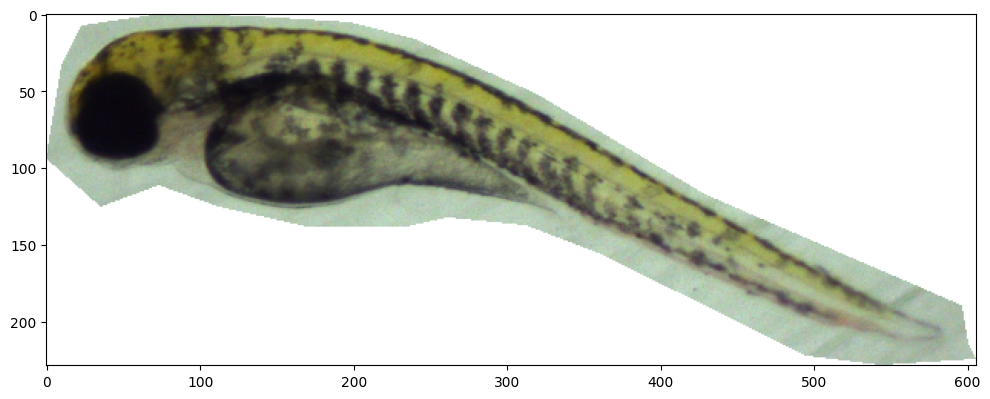

In [9]:
img_path = "images/bst_2.jpeg"

img_preview = cv2.imread(img_path)
img_recortada = recorte_manual(img_preview)

Texto reconhecido: 1mm

Valor extraído: 1.0


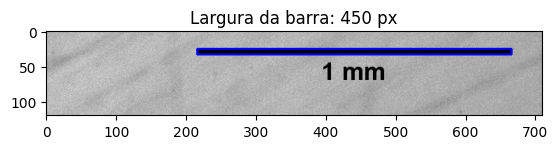

Largura da barra (pixels): 450
Fator de conversão de pixel para mm: 0.0000049 mm/pixel


In [10]:
barra_escala = img_preview.copy()
barra_escala = barra_escala[1800:barra_escala.shape[0],1850:barra_escala.shape[1]]

barra_escala = cv2.cvtColor(barra_escala, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(barra_escala, 50, 255, cv2.THRESH_BINARY_INV)

thresh = cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR)
thresh = cv2.cvtColor(thresh, cv2.COLOR_BGR2GRAY)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

largest_contour = max(contours, key=cv2.contourArea)

x, y, w, h = cv2.boundingRect(largest_contour)

img_color = cv2.cvtColor(barra_escala, cv2.COLOR_GRAY2BGR)
cv2.rectangle(img_color, (x, y), (x+w, y+h), (0, 0, 255), 2)

custom_config = r'--oem 3 --psm 6 -c tessedit_char_whitelist=0123456789.umµ'

texto = pytesseract.image_to_string(barra_escala, config=custom_config)
print("Texto reconhecido:", texto)

match = re.search(r'\d+(?:\.\d+)?', texto)

if match:
    valor = float(match.group())
    print("Valor extraído:", valor)
else:
    print("Número não encontrado")


plt.imshow(img_color)
plt.title(f'Largura da barra: {w} px')
plt.show()

print(f'Largura da barra (pixels): {w}')

fator_conversao = valor/w
fator_conversao = fator_conversao*fator_conversao

print(f'Fator de conversão de pixel para mm: {fator_conversao:.7f} mm/pixel')

fator_conversao = 0.0000049

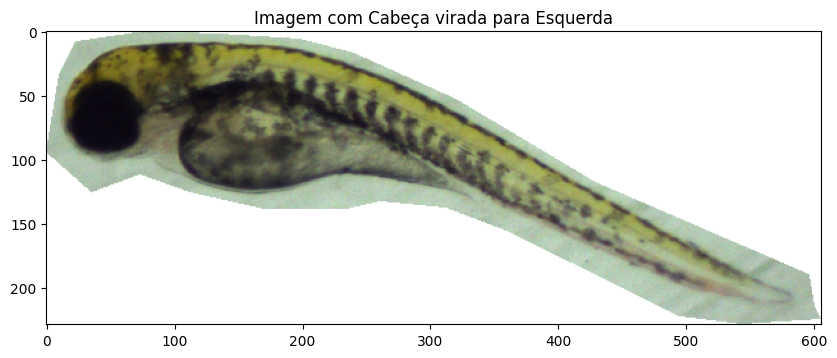

In [11]:
img_color = ensure_head_left(img_recortada)


plt.figure(figsize=(10,5))
plt.imshow(img_color)
plt.title('Imagem com Cabeça virada para Esquerda')
plt.show()


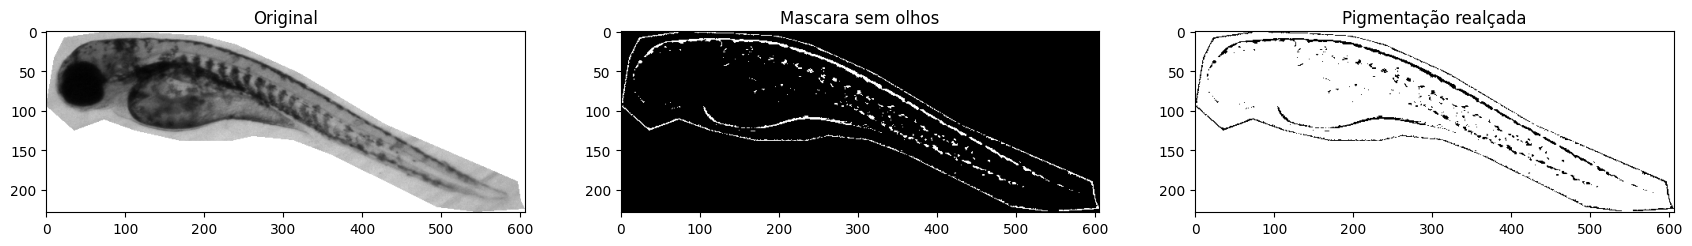

Área pigmentada (sem olhos): 4780 pixels


In [ ]:
img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

x_pig = 15
y_pig = 20

thresh = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY_INV, x_pig, y_pig)
                               #cv2.THRESH_BINARY_INV, 30,35)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

mask_eyes = np.ones_like(img, dtype=np.uint8) * 255
height, width = img.shape

for cnt in contours:
    area = cv2.contourArea(cnt)
    x, y, w, h = cv2.boundingRect(cnt)
    if area > 1000 and x < width * 0.1:
        cv2.drawContours(mask_eyes, [cnt], -1, 3, -1)

# Máscara final sem olhos
pigment_mask = cv2.bitwise_and(thresh, thresh, mask=mask_eyes)

plt.figure(figsize=(21,7)) 
plt.subplot(1,3,1); plt.title('Original'); plt.imshow(img, cmap='gray')
plt.subplot(1,3,2); plt.title('Mascara sem olhos'); plt.imshow(pigment_mask, cmap='gray')
plt.subplot(1,3,3); plt.title('Pigmentação realçada'); plt.imshow(cv2.bitwise_not(pigment_mask), cmap='gray')
plt.show()

pigmented_area = cv2.countNonZero(pigment_mask)
print(f'Área pigmentada (sem olhos): {pigmented_area} pixels')


In [21]:
area_pigmentada = pigmented_area * fator_conversao
print(f'Area Pigmentada: {area_pigmentada:.4f} mm2')
area_pigmentada = area_pigmentada*1000000
print(f'Area Pigmentada: {area_pigmentada:.0f} um2')

Area Pigmentada: 0.0234 mm2
Area Pigmentada: 23422 um2
